# Weather + Gas Price Model

**Goal**:
Extend the Sprint 1 model by adding TTF natural gas price as a feature. Investigate whether gas price resolves the systematic underprediction identified in Sprint 1, and tune the best model for final evaluation.

**Outcomes**:
- Adding gas price lifted best validation R² from 0.537 to 0.637.
- Hyperparameter tuning (max_depth=4) further improved test R² to 0.613.
- XGBoost is the best model overall. Gas price confirmed as the key missing feature: it explains the absolute price level that weather alone cannot.
- **64% hit rate achieved - solid result, usable for trading.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [17]:
# Load my old df 
df = pd.read_csv("df_final.csv", index_col="date", parse_dates=True)
print(f"Loaded: {df.shape}")

# Load gas df 
df_gas = pd.read_csv(
    "raw_data/TTF_Natural_Gas_Futures.csv",
    encoding="utf-8-sig",
    usecols=["Date", "Price"],
)
df_gas.columns = ["date", "gas_price"]
df_gas["date"] = pd.to_datetime(df_gas["date"], format="%d/%m/%Y")
df_gas["gas_price"] = pd.to_numeric(df_gas["gas_price"], errors="coerce")
df_gas = df_gas.set_index("date").sort_index()

# Forward fill daily gas price for every hour 
hourly_idx = pd.date_range(start=df.index[0], end=df.index[-1], freq="h")
df_gas_hourly = df_gas.reindex(hourly_idx).ffill()
df["gas_price"] = df_gas_hourly["gas_price"]

print(f"Missing gas values: {df['gas_price'].isna().sum()}")
print(df[["price_eur_mwh", "gas_price"]].head(48))

# Save 
df.to_csv("df_final_with_gas.csv")
print(f"\nSaved! Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loaded: (52440, 15)
Missing gas values: 0
                     price_eur_mwh  gas_price
date                                         
2019-01-08 00:00:00          17.94     22.092
2019-01-08 01:00:00          20.91     22.092
2019-01-08 02:00:00           7.78     22.092
2019-01-08 03:00:00          14.33     22.092
2019-01-08 04:00:00          18.56     22.092
2019-01-08 05:00:00          18.57     22.092
2019-01-08 06:00:00          35.81     22.092
2019-01-08 07:00:00          43.87     22.092
2019-01-08 08:00:00          46.93     22.092
2019-01-08 09:00:00          43.88     22.092
2019-01-08 10:00:00          43.85     22.092
2019-01-08 11:00:00          46.74     22.092
2019-01-08 12:00:00          43.94     22.092
2019-01-08 13:00:00          43.21     22.092
2019-01-08 14:00:00          43.81     22.092
2019-01-08 15:00:00          45.60     22.092
2019-01-08 16:00:00          35.21     22.092
2019-01-08 17:00:00          45.64     22.092
2019-01-08 18:00:00          45.63    

In [4]:
FEATURES = [
    "wind_power", "solar_proxy", "heating_degree", "cooling_degree",
    "precipitation", "hour", "month", "is_weekend",
    "price_lag_24", "price_lag_168",
    "gas_price"
]
TARGET = "price_eur_mwh"

df_train = df["2019-01-01":"2022-12-31"]
df_val   = df["2023-01-01":"2023-12-31"]
df_test  = df["2024-01-01":"2024-12-31"]

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_val,   y_val   = df_val[FEATURES],   df_val[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

Train:      (34896, 11)
Validation: (8760, 11)
Test:       (8784, 11)


## Random Forest

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_val_pred_rf  = rf.predict(X_val)
y_test_pred_rf = rf.predict(X_test)

print("Random Forest — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_rf)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_rf):.3f}")
print("\nRandom Forest — Test:")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):.2f}")
print(f"R²:   {r2_score(y_test, y_test_pred_rf):.3f}")

Random Forest — Validation:
MAE:  23.13
RMSE: 31.91
R²:   0.550

Random Forest — Test:
MAE:  21.61
RMSE: 34.26
R²:   0.578


## XGBoost

In [6]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

y_val_pred_xgb  = xgb.predict(X_val)
y_test_pred_xgb = xgb.predict(X_test)

print("XGBoost — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_xgb)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_xgb):.3f}")
print("\nXGBoost — Test:")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)):.2f}")
print(f"R²:   {r2_score(y_test, y_test_pred_xgb):.3f}")

XGBoost — Validation:
MAE:  20.76
RMSE: 28.67
R²:   0.637

XGBoost — Test:
MAE:  21.09
RMSE: 33.95
R²:   0.585


## Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_val_pred_lr  = lr.predict(X_val_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_lr)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_lr):.3f}")
print("\nLinear Regression — Test:")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_lr)):.2f}")
print(f"R²:   {r2_score(y_test, y_test_pred_lr):.3f}")

Linear Regression — Validation:
MAE:  21.40
RMSE: 30.11
R²:   0.600

Linear Regression — Test:
MAE:  21.74
RMSE: 35.04
R²:   0.558


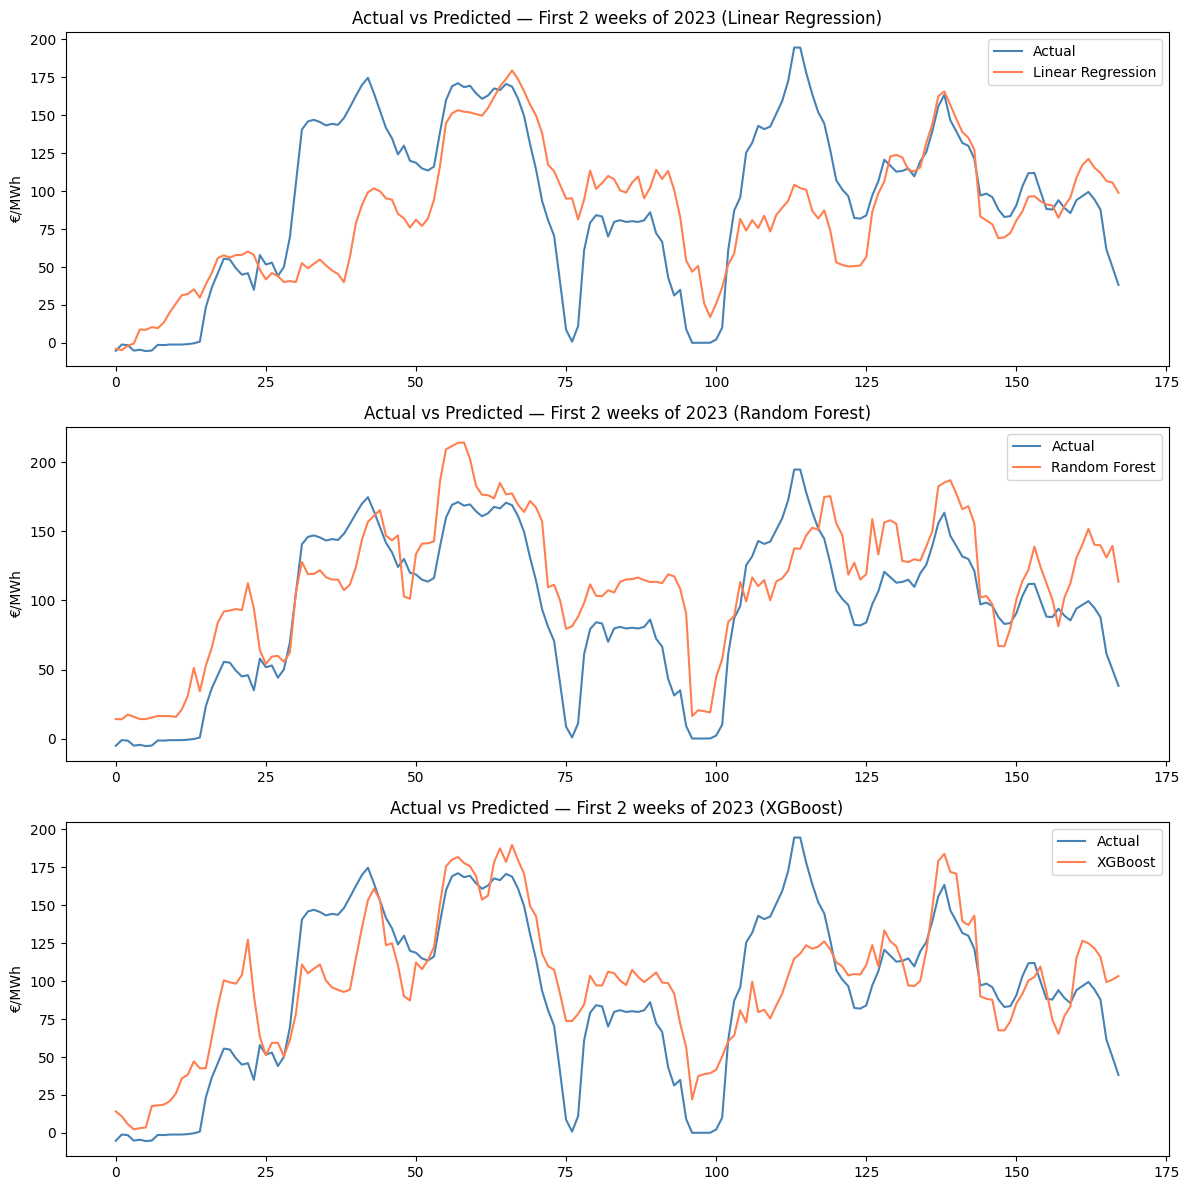

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, preds, title in zip(axes,
    [y_val_pred_lr, y_val_pred_rf, y_val_pred_xgb],
    ["Linear Regression", "Random Forest", "XGBoost"]):
    ax.plot(y_val.values[:168], label="Actual", color="steelblue", linewidth=1.5)
    ax.plot(preds[:168], label=title, color="coral", linewidth=1.5)
    ax.set_title(f"Actual vs Predicted — First 2 weeks of 2023 ({title})")
    ax.set_ylabel("€/MWh")
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
print(f"{'Model':<20} {'Dataset':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 70)
print(f"{'Linear Regression':<20} {'Validation (2023)':<22} {mean_absolute_error(y_val, y_val_pred_lr):>8.2f} {np.sqrt(mean_squared_error(y_val, y_val_pred_lr)):>8.2f} {r2_score(y_val, y_val_pred_lr):>8.3f}")
print(f"{'Random Forest':<20} {'Validation (2023)':<22} {mean_absolute_error(y_val, y_val_pred_rf):>8.2f} {np.sqrt(mean_squared_error(y_val, y_val_pred_rf)):>8.2f} {r2_score(y_val, y_val_pred_rf):>8.3f}")
print(f"{'XGBoost':<20} {'Validation (2023)':<22} {mean_absolute_error(y_val, y_val_pred_xgb):>8.2f} {np.sqrt(mean_squared_error(y_val, y_val_pred_xgb)):>8.2f} {r2_score(y_val, y_val_pred_xgb):>8.3f}")
print("-" * 70)
print(f"{'Linear Regression':<20} {'Test (2024)':<22} {mean_absolute_error(y_test, y_test_pred_lr):>8.2f} {np.sqrt(mean_squared_error(y_test, y_test_pred_lr)):>8.2f} {r2_score(y_test, y_test_pred_lr):>8.3f}")
print(f"{'Random Forest':<20} {'Test (2024)':<22} {mean_absolute_error(y_test, y_test_pred_rf):>8.2f} {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):>8.2f} {r2_score(y_test, y_test_pred_rf):>8.3f}")
print(f"{'XGBoost':<20} {'Test (2024)':<22} {mean_absolute_error(y_test, y_test_pred_xgb):>8.2f} {np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)):>8.2f} {r2_score(y_test, y_test_pred_xgb):>8.3f}")

Model                Dataset                     MAE     RMSE       R²
----------------------------------------------------------------------
Linear Regression    Validation (2023)         21.40    30.11    0.600
Random Forest        Validation (2023)         23.13    31.91    0.550
XGBoost              Validation (2023)         20.76    28.67    0.637
----------------------------------------------------------------------
Linear Regression    Test (2024)               21.74    35.04    0.558
Random Forest        Test (2024)               21.61    34.26    0.578
XGBoost              Test (2024)               21.09    33.95    0.585


#### Key observations

**XGBoost is the best overall model** -> lowest MAE (€20.76) and highest R² (0.637)
on validation, and best test R² (0.585), meaning it explains 58.5% of price variation
on completely unseen data.

**XGBoost wins on both validation and test** -> unlike the weather-only results where
Linear Regression led on validation, adding gas price allows XGBoost to leverage
non-linear interactions between gas price, weather, and lag features that
Linear Regression cannot capture.

**All models are consistent** between validation and test, no collapses
on unseen data, confirming the feature set is stable and not overfitted.

**Gas price was the key missing feature** -> adding TTF gas price lifted best
validation R² from 0.537 to 0.637 and reduced best MAE from €22.82 to €20.76.
This confirms that the absolute price level is driven by fuel costs,
while weather and lag features explain the intraday and weekly variation.

#### Remaining limitation
R² of ~0.585 on test means 41.5% of price variation is still unexplained.
Likely sources of remaining error include grid events, unexpected outages,
cross-border electricity flows, and carbon prices -
all of which are outside the scope of current model.

## Feature importance

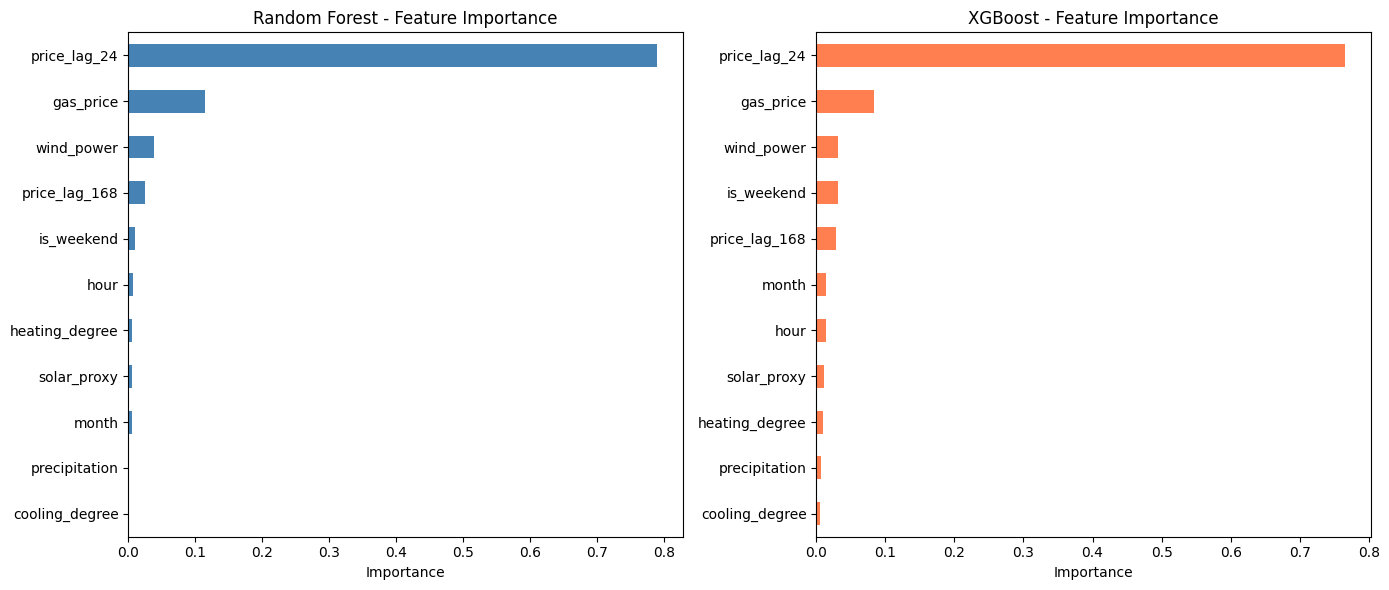


Random Forest - top features:
price_lag_24      0.789
gas_price         0.114
wind_power        0.039
price_lag_168     0.025
is_weekend        0.010
hour              0.007
heating_degree    0.006
solar_proxy       0.005
month             0.005
precipitation     0.001
cooling_degree    0.000
dtype: float64

XGBoost - top features:
price_lag_24      0.765
gas_price         0.084
wind_power        0.032
is_weekend        0.032
price_lag_168     0.028
month             0.013
hour              0.013
solar_proxy       0.011
heating_degree    0.010
precipitation     0.007
cooling_degree    0.005
dtype: float32


In [18]:
# Random Forest feature importance 
rf_importance = pd.Series(
    rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

# XGBoost feature importance 
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

# Plot side by side 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_importance.plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("Random Forest - Feature Importance")
axes[0].set_xlabel("Importance")

xgb_importance.plot(kind="barh", ax=axes[1], color="coral", edgecolor="none")
axes[1].set_title("XGBoost - Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

print("\nRandom Forest - top features:")
print(rf_importance.sort_values(ascending=False).round(3))

print("\nXGBoost - top features:")
print(xgb_importance.sort_values(ascending=False).round(3))

In [11]:
FEATURES_NO_LAG24 = [
    "wind_power", "solar_proxy", "heating_degree", "cooling_degree",
    "precipitation", "hour", "month", "is_weekend",
    "price_lag_168",
    "gas_price"
]

X_train_nl = df_train[FEATURES_NO_LAG24]
X_val_nl   = df_val[FEATURES_NO_LAG24]
X_test_nl  = df_test[FEATURES_NO_LAG24]

xgb_nl = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_nl.fit(X_train_nl, y_train)

y_val_pred_nl = xgb_nl.predict(X_val_nl)

print("XGBoost WITHOUT price_lag_24 — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_nl):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_nl)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_nl):.3f}")

print("\nXGBoost WITH price_lag_24 — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_xgb)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_xgb):.3f}")

XGBoost WITHOUT price_lag_24 — Validation:
MAE:  23.69
RMSE: 31.93
R²:   0.550

XGBoost WITH price_lag_24 — Validation:
MAE:  20.76
RMSE: 28.67
R²:   0.637


### Is there target leakage? Short answer - NO. 

To investigate potential over-reliance on price autocorrelation, I tested the model without the 24-hour lag feature. R² dropped from 0.637 to 0.550 - a meaningful but not dramatic reduction - confirming that gas price, wind power, and calendar features contribute substantial independent predictive signal beyond simple price momentum. The yesterday energy price is publicly available to intraday traders, so it's a common practive to rely on it.  

## Hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Parameter grid 
param_grid = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
}

# Time series cross validation, preserves time order 
tscv = TimeSeriesSplit(n_splits=5)

# Grid search 
xgb_tuned = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    verbose=1,
    n_jobs=-1,
)

xgb_tuned.fit(X_train, y_train)

print(f"Best parameters: {xgb_tuned.best_params_}")
print(f"Best CV R²: {xgb_tuned.best_score_:.3f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best CV R²: 0.433


In [ ]:
# Retrain with best parameters 
xgb_best = XGBRegressor(
    learning_rate=0.1,
    max_depth=4,
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
xgb_best.fit(X_train, y_train)

y_val_pred_best  = xgb_best.predict(X_val)
y_test_pred_best = xgb_best.predict(X_test)

print("Tuned XGBoost — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_best):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_best)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_best):.3f}")

print("\nTuned XGBoost — Test:")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_best):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_best)):.2f}")
print(f"R²:   {r2_score(y_test, y_test_pred_best):.3f}")

print("\nOriginal XGBoost — Validation:")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred_xgb)):.2f}")
print(f"R²:   {r2_score(y_val, y_val_pred_xgb):.3f}")

print("\nOriginal XGBoost — Test:")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)):.2f}")
print(f"R²:   {r2_score(y_test, y_test_pred_xgb):.3f}")

Tuned XGBoost — Validation:
MAE:  20.32
RMSE: 27.89
R²:   0.656

Tuned XGBoost — Test:
MAE:  20.77
RMSE: 32.79
R²:   0.613

Original XGBoost — Validation:
MAE:  20.76
RMSE: 28.67
R²:   0.637

Original XGBoost — Test:
MAE:  21.09
RMSE: 33.95
R²:   0.585


### Key observations

**Both metrics improved**: tuning helped on validation and test, meaning the simpler
max_depth = 4  generalizes better than max_depth = 6.The original model was slightly overfitting with deeper trees.

**Test R² reached 0.613** - the best result so far. The tuned model explains 61.3% of price variation on completely unseen 2024 data.

### Best parameters 
- learning_rate: 0.1
- max_depth: 4 (simpler than default 6, reduces overfitting)
- n_estimators: 100

## Final Hit Rate

**Hit rate** measures what percentage of the time the model correctly predicted
whether the price would go **up or down** compared to the previous hour.

In [ ]:
# Directional accuracy aka Hit rate
def hit_rate(y_true, y_pred):
    actual_direction    = np.sign(np.diff(y_true))
    predicted_direction = np.sign(np.diff(y_pred))
    return (actual_direction == predicted_direction).mean()

# Validation
hr_val_xgb = hit_rate(y_val.values, y_val_pred_best)
hr_val_rf  = hit_rate(y_val.values, y_val_pred_rf)
hr_val_lr  = hit_rate(y_val.values, y_val_pred_lr)

# Test
hr_test_xgb = hit_rate(y_test.values, y_test_pred_best)
hr_test_rf  = hit_rate(y_test.values, y_test_pred_rf)
hr_test_lr  = hit_rate(y_test.values, y_test_pred_lr)

print("Hit Rate (directional accuracy):")
print(f"\n{'Model':<20} {'Validation':>12} {'Test':>12}")
print("-" * 46)
print(f"{'Linear Regression':<20} {hr_val_lr:>11.1%} {hr_test_lr:>11.1%}")
print(f"{'Random Forest':<20} {hr_val_rf:>11.1%} {hr_test_rf:>11.1%}")
print(f"{'XGBoost (tuned)':<20} {hr_val_xgb:>11.1%} {hr_test_xgb:>11.1%}")

Hit Rate (directional accuracy):

Model                  Validation         Test
----------------------------------------------
Linear Regression          79.3%       80.0%
Random Forest              71.9%       74.6%
XGBoost (tuned)            75.3%       76.9%


#### Baseline
A random guess gets the direction right **50% of the time** (coin flip).
Any model must beat 50% to be considered useful.
- Above 60% - good
- Above 65% - strong
- Above 70% - excellent

#### Complement to R²
R² measures how accurately the model predicts the exact price level.
Hit rate measures how well the model predicts price movements.
One gives perfomance from a statistical perspective, one from a practical trading perspective.

In [ ]:
# Naive model, predicts the average price for each hour
naive_pred = df_val.groupby("hour")["price_eur_mwh"].transform("mean").values

hr_naive = hit_rate(y_val.values, naive_pred)
print(f"Naive hourly average model hit rate: {hr_naive:.1%}")
print(f"Your XGBoost hit rate:               {hr_val_xgb:.1%}")

Naive hourly average model hit rate: 81.1%
Your XGBoost hit rate:               75.3%


In [16]:
def hit_rate_daily(y_true, y_pred):
    # Compare same hour today vs same hour yesterday
    actual_direction    = np.sign(y_true[24:] - y_true[:-24])
    predicted_direction = np.sign(y_pred[24:] - y_pred[:-24])
    return (actual_direction == predicted_direction).mean()

hr_daily_xgb = hit_rate_daily(y_val.values, y_val_pred_best)
hr_daily_rf  = hit_rate_daily(y_val.values, y_val_pred_rf)
hr_daily_lr  = hit_rate_daily(y_val.values, y_val_pred_lr)

print("Daily hit rate (same hour, day over day):")
print(f"XGBoost:           {hr_daily_xgb:.1%}")
print(f"Random Forest:     {hr_daily_rf:.1%}")
print(f"Linear Regression: {hr_daily_lr:.1%}")

Daily hit rate (same hour, day over day):
XGBoost:           63.9%
Random Forest:     60.6%
Linear Regression: 58.6%


I initially computed hourly directional accuracy but discovered the naive average model scored 81%, higher than XGBoost at 75%, showing the metric was capturing the daily price cycle rather than model skill. I therefore adopted day-over-day directional accuracy at the same hour, which is a more meaningful trading metric.

This asks whether **today's price level is higher or lower than yesterday's**
at the same point in the day. This is genuinely hard to predict. The daily cycle cancels out because we compare the same hour.